# Atividade 1 - Processamento Digital de Imagens

## Imports

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

## Setup

In [ ]:
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['image.cmap'] = 'gray'

IMG_PATH = Path('earth.jpg')
OUT_DIR = Path('outputs')

def load_image(path=IMG_PATH):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Imagem nao encontrada: {path.resolve()}')
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f'Nao foi possivel ler a imagem: {path.resolve()}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def save_image(filename, img, out_dir=OUT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    arr = np.clip(img, 0, 255).astype(np.uint8)
    if arr.ndim == 3 and arr.shape[2] == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    ok = cv2.imwrite(str(out_path), arr)
    if not ok:
        raise ValueError(f'Falha ao salvar imagem em: {out_path.resolve()}')
    return out_path

def show_image(title, img, cmap=None):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()
    
img = load_image(IMG_PATH)
img_gray = (0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]).astype(np.uint8)
save_image('img_gray.png', img_gray)

## Questao 1 - Efeito de esboco a lapis
Passos: (i) RGB -> cinza, (ii) desfoque gaussiano manual (mascara 21x21), (iii) divisao cinza/desfocada.

In [ ]:
# TODO Q1: implementar as funcoes manualmente
def rgb_to_gray_manual(img_rgb):
    # Exemplo esperado: 0.299*R + 0.587*G + 0.114*B
    pass

def gaussian_kernel(size=21, sigma=5.0):
    pass

def convolve2d_manual(img, kernel):
    pass

def pencil_sketch_effect(img_rgb):
    pass

# Execucao Q1
# img_rgb = load_image(IMG_PATH)
# sketch = pencil_sketch_effect(img_rgb)
# show_image('Q1 - Sketch', sketch)
# save_image('q1_sketch.png', sketch)

## Questão 2 - Correção Gama

In [ ]:
gammas = [0.5, 1.0, 1.5, 2.0]

# (i) 
img_float = img_gray.astype(np.float32) / 255.0

# (ii) 
results = []
for g in gammas:
    corrected = np.power(img_float, 1.0 / g)
    # (iii) 
    out = np.clip(corrected * 255.0, 0, 255).astype(np.uint8)
    results.append((g, out))

for g, out in results:
    show_image(f'Q2 - gamma={g}', out)
    out_name = f"q2_gamma_{str(g).replace('.', '_')}.png"
    save_path = save_image(out_name, out)
    print(f'Salvo: {save_path}')

## Questao 3 - Media ponderada de duas imagens
Combinar duas imagens monocromaticas do mesmo tamanho.

In [ ]:
# TODO Q3
def weighted_average_manual(img_a, img_b, alpha=0.5):
    # beta = 1 - alpha
    pass

# Execucao Q3
# out = weighted_average_manual(img1, img2, alpha=0.7)
# show_image('Q3 - Media ponderada', out)

## Questão 4 - Transformações

In [ ]:
# b)
negative = 255 - img_gray

# c)
interval = ((img_gray.astype(np.float32) / 255.0) * (200 - 100) + 100).astype(np.uint8)

# d)
even_rows_reversed = img_gray.copy()
even_rows_reversed[0::2] = even_rows_reversed[0::2, ::-1]

# e)
mirror_top_to_bottom = img_gray.copy()
rows = mirror_top_to_bottom.shape[0]
half = rows // 2
mirror_top_to_bottom[rows - half:] = mirror_top_to_bottom[:half][::-1]

# f)
vertical_mirror = img_gray[::-1, :].copy()

save_image('q4b_negativo.png', negative)
save_image('q4c_intervalo_100_200.png', interval)
save_image('q4d_linhas_pares_invertidas.png', even_rows_reversed)
save_image('q4e_metade_superior_espelhada.png', mirror_top_to_bottom)
save_image('q4f_espelhamento_vertical.png', vertical_mirror)

show_image('Q4b - Negativo', negative)
show_image('Q4c - Intervalo [100, 200]', interval)
show_image('Q4d - Linhas pares invertidas', even_rows_reversed)
show_image('Q4e - Metade superior espelhada na inferior', mirror_top_to_bottom)
show_image('Q4f - Espelhamento vertical', vertical_mirror)

## Questao 5 - Mosaico 4x4
Construir mosaico de 16 blocos a partir de imagem monocromatica.

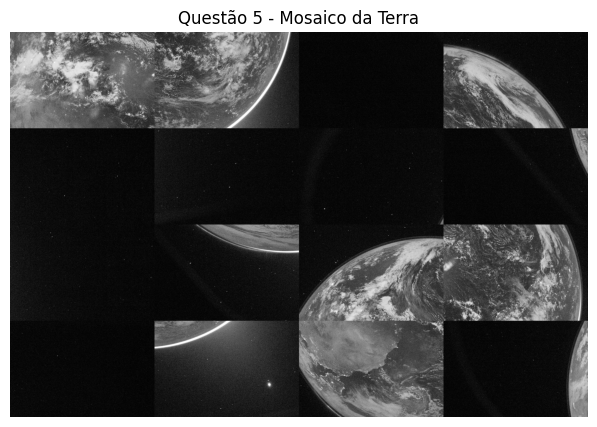

PosixPath('outputs/q5_mosaico_terra.png')

In [ ]:
h, w = img_gray.shape
bh, bw = h // 4, w // 4


blocos = []
for r in range(4):
    for c in range(4):
        
        b = img_gray[r*bh : (r+1)*bh, c*bw : (c+1)*bw]
        blocos.append(b)

nova_ordem = [
    6, 11, 13, 3,
    8, 16, 1, 9,
    12, 14, 2, 7,
    4, 15, 10, 5
]
nova_ordem = [n - 1 for n in nova_ordem] 

mosaico = np.zeros_like(img_gray)

for i in range(16):
    
    r_dest = i // 4
    c_dest = i % 4
    
    indice_bloco_origem = nova_ordem[i]
    
    mosaico[r_dest*bh : (r_dest+1)*bh, c_dest*bw : (c_dest+1)*bw] = blocos[indice_bloco_origem]

# 5. Resultado
show_image('Questão 5 - Mosaico da Terra', mosaico)
save_image('q5_mosaico_terra.png', mosaico)

## Questão 6 - Quantização

In [ ]:
quantization_levels = [2, 4, 8, 16, 32, 64]

for levels in quantization_levels:
    # Map to quantization bins [0, levels-1] and rescale to [0, 255]
    bin_img = (img_gray.astype(np.float32) * levels) / 256.0
    bin_img = np.floor(bin_img)
    img_quant = (bin_img * (255.0 / (levels - 1))).astype(np.uint8)

    show_image(f'Q6 - Quantized ({levels} levels)', img_quant)
    save_image(f'q6_quant_{levels}.png', img_quant)
    
show_image('Q6 - Original (256 levels)', img_gray)

## Bloco de conclusoes para o relatorio
- Descreva o que foi implementado em cada questao.
- Inclua comparacoes visuais e interpretacoes.
- Registre insights sobre os efeitos observados.